In [1]:
%load_ext autoreload
%autoreload 2

import os
import json
import cv2
import numpy as np
import torch
import glob
import torch.nn as nn

import tqdm # For progress bars

from yolo.yolo import Yolo

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device('cuda')
print(device)

cuda


In [3]:
class_dict = {
    'Head': 0,
    'RShoulder': 1,
    'LShoulder': 2,
    'LElbow': 3,
    'LWrist': 4,
    'RHip': 5,
    'LHip': 6,
    'LKnee': 7,
    'RKnee': 8,
    'RAnkle': 9,
    'LAnkle': 10,
    'RElbow': 11,
    'RWrist': 12,
    'Neck': 13
}

In [4]:
def Json_to_yolo_formate(json_data, img_width, img_height):
    yolo_data = []
    for shape in json_data['shapes']:
        x1, y1 = shape['points'][0]
        x2, y2 = shape['points'][1]
        x_left = x1 / img_width
        y_top = y1 / img_height
        width = (x2 - x1) / img_width
        height = (y2 - y1) / img_height
        class_id = class_dict[shape['label']]
        yolo_data.append([class_id, x_left, y_top, width, height])
    return yolo_data

def save_yolo_formate(json_data):
    image_name = json_data['imagePath'].split('.')[0]
    image_path = f"./dataset/{image_name}.png"
#     print(image_path)
    img = cv2.imread(image_path)
    h, w, _ = img.shape
    yolo_data = Json_to_yolo_formate(json_data, w, h)
    directory = './dataset/annotation_percentage/'
    if not os.path.exists(directory):
        os.makedirs(directory)
    with open (f'{directory}{image_name}.txt', 'w') as f:
        for data in yolo_data:
            f.write(' '.join(map(str, data)) + '\n')

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import cv2

normal_size = (128,128)

def load_image(path):
    return cv2.imread(path)

def load_json(path):
    with open(path, 'r') as f:
        return json.load(f)

def crop_image(image, coords):
    x1, y1 = coords[0]
    x2, y2 = coords[1]
    return image[int(y1):int(y2), int(x1):int(x2)]

def show_image_detail(image, json):
    plt.imshow(image)
    fig, axs = plt.subplots(1, len(json['shapes']), figsize=(15, 15))
    for i, shape in enumerate(json['shapes']):
        croped_test_img = crop_image(image, shape['points'])
        croped_test_img = resize_image(croped_test_img)
        print(croped_test_img.shape)
        axs[i].imshow(croped_test_img)
        axs[i].set_title(shape['label'])
    plt.show()

def resize_image(image, size=normal_size):
    return cv2.resize(image, size)

def vaildate_yolo_formate(path):
    imag = cv2.imread(path)
    yolo_path = os.path.join('dataset', 'annotation_percentage', os.path.basename(path).split('.')[0] + '.txt')
    with open(yolo_path, 'r') as boxes:
        for box in boxes:
            box = box.split(' ')
            class_id, x_center, y_center, width, height = map(float, box)
            x1 = int(x_center - width/2)
            y1 = int(y_center - height/2)
            x2 = int(x_center + width/2)
            y2 = int(y_center + height/2)
            cv2.rectangle(imag, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(imag, str(int(class_id)), (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 5, (0, 0, 255), 5)
    imag = cv2.cvtColor(imag, cv2.COLOR_BGR2RGB)
    plt.imshow(imag)
    plt.show()

In [6]:
# json_paths = glob.glob('dataset/*.json')
# for json_path in tqdm.tqdm(json_paths):
#     json_data = load_json(json_path)
#     save_yolo_formate(json_data)

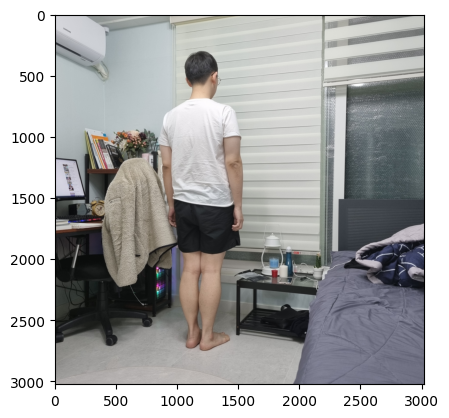

In [7]:
vaildate_yolo_formate('dataset/stand_b_74.png')

In [8]:
def iou(boxes1, boxes2): # box = [x_center, y_center, width, height]
    ious = []
    for box1, box2 in zip(boxes1, boxes2):
        x11, y11, x12, y12 = box1[0] - box1[2]/2, box1[1] - box1[3]/2, box1[0]  + box1[2]/2, box1[1] + box1[3]/2
        x21, y21, x22, y22 = box2[0] - box2[2]/2, box2[1] - box2[3]/2, box2[0]  + box2[2]/2, box2[1] + box2[3]/2

        x_inter1, y_inter1 = max(x11, x21), max(y11, y21)
        x_inter2, t_inter2 = min(x12, x22), min(y12, y22)

        intersection = abs(x_inter2 - x_inter1) * abs(y_inter1 - t_inter2)

        box1_area, box2_area = box1[2] * box1[3], box2[2] * box2[3]
        ious.append(intersection / (box1_area + box2_area - intersection))
    return ious

box1 = [[1, 1, 2, 2], [1, 1, 2, 2]]
box2 = [[2, 1, 2, 2], [3,1,2,2]]
test = iou(box1, box2)
print(test)
    

[0.3333333333333333, 0.0]


In [9]:
box1 = [1,1,2,2]
box2 = [2,1,2,2]
print(iou([box1], [box2]))

[0.3333333333333333]


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import glob
class backDataset(Dataset):
    def __init__(self, transform=None, anchor_boxes = None):
        self.img_paths = glob.glob('dataset/*.png')
        self.transform = transform
        self.anchor_boxes = anchor_boxes * (416/1920)
    def __len__(self):
        return len(self.img_paths)
    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        original_h, original_w = img.shape[:2]
        normalize = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((416, 416)),
            transforms.ToTensor()
        ])
        with open(os.path.join('dataset', 'annotation_percentage', os.path.basename(self.img_paths[idx]).replace('.png', '.txt'))) as f:
            all_boxes = []
            for line in f.readlines():
                class_id, px, py, pw, ph = map(float, line.strip().split(' ')) # class_id, % x, % y, % w, % h
                
                boxes = []
                for scale in [13, 26, 52]:
                    new_box = torch.zeros(25) # create tensor with 4 + 1 + 14 length + 2 (for px, py)

                    # Assign basic values that no need to compute (..., obj, ..., class, ...)
                    new_box[4] = 1  # Automatically at 1.0 because obv. object
                    new_box[int(class_id + 5)] = 1
                    new_box[-2] = pw
                    new_box[-1] = ph

                    # Assign center offset percentage
                    new_box[-4] = px + (pw / 2) # Set x position percentage to gt_bb center
                    new_box[-3] = py + (ph / 2) # Set y position percentage to gt_bb center
                    
                    # Assign raw tw, th offset
                    new_box[[2, 3]] = torch.tensor([pw * scale, ph * scale])
                    
                    # Compute tx, ty based on raw coordinate offset
                    raw_coord = torch.tensor([new_box[-4] * scale, new_box[-3] * scale])
                    cell_coord = raw_coord // 1
                    new_box[[0, 1]] = raw_coord - cell_coord
                    
                    # Get best anchor for this scale                    
                    best_anchor = [None, -1]  # [[anchor_w, anchor_h]_scaled, anchor_iou]
                    for anchor in self.anchor_boxes:
                        anchor_iou = iou([[0, 0, new_box[2], new_box[3]]], [[0, 0] + (anchor / scale).tolist()])
                        if anchor_iou[0] > best_anchor[1]:
                            best_anchor = [anchor / scale, anchor_iou[0]]
                    new_box[[-6, -5]] = best_anchor[0]
                    
                    # Adjust raw tw, th to real tw th
#                     print(new_box[[2, 3]], '|', best_anchor[0], '|', new_box[[2, 3]] / best_anchor[0])
                    new_box[[2, 3]] = new_box[[2, 3]] / best_anchor[0] # This will give the exp(tw) and exp(th) to get from anchor to gt

                    boxes.append(new_box)
                all_boxes.append(torch.stack(boxes))
#                 print(all_boxes[-1])
        img = normalize(img)
        return img, torch.stack(all_boxes)

From the above, the expected output is a size `23` vector that mimics the vector expected from predictions.  

Expected shape is `[num_boxes_img, 3 (num_scales), bounding_box_vector]`. The first two sizes are self explanatory. 
The last size is the `23` size bounding box vector relative to an anchor box that was assigned. The elements are:  
`[tx, ty, exp(tw), exp(th), obj, ...classes probs... x 14, aw, wh, px, py, pw, ph]` such that `px, py`, `pw, ph` are the percentage coordinates and w/h of the ground truth bounding box. `aw, ah` is the assigned anchor box's width and height (already scaled) (may remove if not needed). `tx, ty, tw, th` are the absolutes, i.e. `tx` is `tx` away from the left of the cell, `tw` is the width of the bounding box times `tw`.

For extracting information, make sure to use `box[:19]` to not get the last 4 meta data elements (unless needed).

Example:  
`torch.Size([14, 3, 23])`  

This means `14` boxes in img, for each box, there's a size `23` vector for each of the `3` scales. **The scales are already computed, no need to scale again**

In [11]:
def show_img_box(img, data):
    tmp_img = img.permute(1, 2, 0)
    tmp_img = cv2.cvtColor(tmp_img.numpy(), cv2.COLOR_BGR2RGB)
    for box in data:
        class_id = torch.argmax(box[0][5:19])
        box_dim = (box[0][[-2, -1]] * 416)
        x1, y1 = (box[0][[-4, -3]] * 416) - (box_dim / 2) 
        x2, y2 = (box[0][[-4, -3]] * 416) + (box_dim / 2) 
        cv2.rectangle(tmp_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
        cv2.putText(tmp_img, str(int(class_id)), (int(x1), int(y1)), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 1)
    plt.imshow(tmp_img)


In [12]:
anchors = torch.tensor([[151.37092679, 151.37092679], [116.1775567, 116.1775567 ], [ 69.10933737,  69.10933737], 
                        [206.27557981, 206.27557981], [257.97346109, 257.97346109]])

In [13]:
test_loader = DataLoader(backDataset(anchor_boxes=anchors), batch_size=1, shuffle=True)

In [14]:
img, data = test_loader.dataset[0]

In [15]:
print(data.shape)
data[0]

torch.Size([14, 3, 25])


tensor([[0.7653, 0.1273, 0.5923, 0.5923, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.1518, 1.1518, 0.5204, 0.0867, 0.0525, 0.0525],
        [0.5306, 0.2546, 1.0817, 1.0817, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.2614, 1.2614, 0.5204, 0.0867, 0.0525, 0.0525],
        [0.0613, 0.5093, 2.5389, 2.5389, 1.0000, 1.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 1.0749, 1.0749, 0.5204, 0.0867, 0.0525, 0.0525]])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


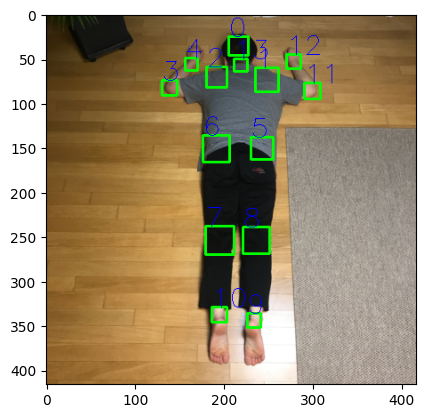

In [16]:
show_img_box(img, data)

In [17]:
from torch.utils.data import DataLoader, random_split
from torchvision import transforms

def collate_fn(batch): # each item in batch is (x, y)
    img = [item[0] for item in batch]
    boxes = [item[1] for item in batch]
    max_boxes = max([len(box) for box in boxes])
    boxes_list_padded = []
    for box in boxes:
        if box.shape[0] < max_boxes:
            box = torch.cat([box, torch.zeros(max_boxes - box.shape[0], box.shape[1], box.shape[2])])
        boxes_list_padded.append(box)
    return torch.stack(img), torch.stack(boxes_list_padded)


dataset = backDataset(anchor_boxes=anchors)
train_size = int(0.7 * len(dataset))
val_size = int(0.1 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True, collate_fn=collate_fn)

In [18]:
test_train_img, test_train_data = next(iter(train_loader))
print(test_train_img.shape)
print(test_train_data.shape)

torch.Size([10, 3, 416, 416])
torch.Size([10, 14, 3, 25])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


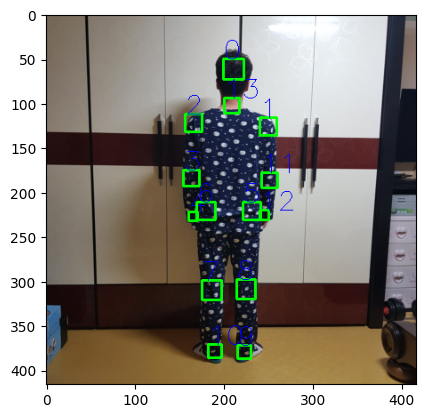

In [19]:
show_img_box(test_train_img[0], test_train_data[0])

# YOLO
Yolov3 (might be easier)
https://blog.paperspace.com/how-to-implement-a-yolo-object-detector-in-pytorch/
https://arxiv.org/abs/1804.02767

In [20]:
tt, td = next(iter(train_loader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


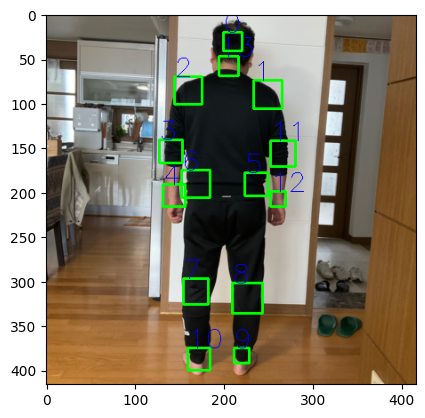

In [21]:
show_img_box(tt[0], td[0])

In [22]:
tt.shape

torch.Size([10, 3, 416, 416])

In [23]:
yolo_test = Yolo(14, anchors.shape[0]).to(device)
tt = tt.to(device)

In [24]:
test_result = yolo_test(tt)
test_result = [result.permute(0, 2, 3, 1) for result in test_result] # need to permute to (x, y, 95) b/c 95 is layers, not prediciton list as wanted

begin yolo
start backbone block 1
post block 1 torch.Size([10, 64, 208, 208])
start block 2
block 2 pre-res
post block 2 torch.Size([10, 128, 104, 104])
start block 3
block 3 pre-res
post block 3 torch.Size([10, 256, 52, 52])
start block 4
block 4 pre-res
post block 4 torch.Size([10, 512, 26, 26])
start block 5
block 5 pre-res
post block 5 torch.Size([10, 1024, 13, 13])
backbone end return
torch.Size([10, 1024, 13, 13])
torch.Size([10, 512, 26, 26])
torch.Size([10, 256, 52, 52])
torch.Size([10, 1024, 13, 13])
l2p torch.Size([10, 512, 13, 13])
torch.Size([10, 512, 26, 26])
torch.Size([10, 512, 26, 26]) torch.Size([10, 512, 26, 26])
l2p torch.Size([10, 256, 26, 26])
torch.Size([10, 256, 52, 52])
torch.Size([10, 256, 52, 52]) torch.Size([10, 256, 52, 52])
l2p torch.Size([10, 128, 52, 52])


In [31]:
print(td[0].shape)

torch.Size([14, 3, 25])


In [80]:
class MultiFactorLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.mseloss = nn.MSELoss()
        
    def bounding_loss(self, anchors, ground_truths, img_scale, scale_down):
        anchors = anchors // scale_down

    #     for i in range(img_scale.shape[0]):
    #         for j in range(img_scale.shape[1]):
    #             # Get cell center
    #             c_x = i + 0.5   # ith cell (top left corner) + 0.5 center offset
    #             c_y = j + 0.5   # jth cell (top left corner) + 0.5 center offset

    #             # Get prediction offsets
    #             prediction = img_scale[i][j]
    #             t_x, t_y, t_w, t_l = prediction[:4]

    #             # Iterate through all anchors
    #             main_loss = 0    # main loss for the anchor that has the highest IoU with 
    #             for (p_w, p_l) in anchors:
    #                 b_x = torch.sigmoid(t_x) + c_x
    #                 b_y = torch.sigmoid(t_y) + c_y
    #                 b_w = p_w * torch.exp(t_w)
    #                 b_l = p_l * torch.exp(t_l)


        '''
        TODO From Paper:
        During training we use sum of squared error loss. If the
        ground truth for some coordinate prediction is tˆ*
        our gradient is the ground truth value (computed from the ground
        truth box) minus our prediction: tˆ* − t*. This ground truth
        value can be easily computed by inverting the equations above.
        '''
        mse_losses = []
        for row in img_scale:
            for cell in row:
                pred_boxes = torch.stack(torch.split(cell, (19,) * (cell.shape[0] // 19))) # Split up to each anchor box in own tensor

                # Compute sigmoid for tx, ty and exp for tw, th
                pred_boxes[:, 0:2] = torch.sigmoid(pred_boxes[:, 0:2])
                pred_boxes[:, 2:4] = torch.exp(pred_boxes[:, 2:4])

                # Find best prediction anchor box in terms of IoU (NOT DOING) Or use as a way to weigh the losses in respect to IoU

                # Compute loss between predict's anchor boxes and the all gt anchor boxes
                for box in pred_boxes:
                    mse_losses.append(torch.sum(torch.tensor([self.mseloss(box[0:4], gt[0:4].to(device)) for gt in ground_truths])))

        return torch.mean(torch.tensor(mse_losses))

    def bounding_loss_batch(self, anchors, true_y, pred_y):
        '''
        Loss function for bounding boxes. 
        Assumes predict_boxes in shape [b, x, y, c]. 
        Assumes ground_truths to be original resolution. Loss function will down scale.
        '''
        ground_truths = true_y.permute(1, 0, 2) # Permute to cluster into scales for zipping
        
        for scale_down, gt, img_scales in zip([32, 16, 8], ground_truths, pred_y):   # iterate through each scale
            print()
            print(img_scales.shape)
            for scale in img_scales:
                print(f'Scale: 416x416 -> {416//scale_down}x{416//scale_down} (/{scale_down})')
                loss = self.bounding_loss(anchors, gt, scale, scale_down)
                print(loss)

In [81]:
criterion = MultiFactorLoss()

In [82]:
criterion.bounding_loss_batch(anchors, td[0], test_result)


torch.Size([10, 13, 13, 95])
Scale: 416x416 -> 13x13 (/32)
tensor(4.5175)
Scale: 416x416 -> 13x13 (/32)
tensor(2.3307)
Scale: 416x416 -> 13x13 (/32)
tensor(3.1261)
Scale: 416x416 -> 13x13 (/32)
tensor(13.2297)
Scale: 416x416 -> 13x13 (/32)
tensor(2.3825)
Scale: 416x416 -> 13x13 (/32)
tensor(2.9044)
Scale: 416x416 -> 13x13 (/32)
tensor(7.4437)
Scale: 416x416 -> 13x13 (/32)
tensor(2.9812)
Scale: 416x416 -> 13x13 (/32)
tensor(2.9142)
Scale: 416x416 -> 13x13 (/32)
tensor(2.6074)

torch.Size([10, 26, 26, 95])
Scale: 416x416 -> 26x26 (/16)
tensor(2.8835)
Scale: 416x416 -> 26x26 (/16)
tensor(1.4973)
Scale: 416x416 -> 26x26 (/16)
tensor(2.0967)
Scale: 416x416 -> 26x26 (/16)
tensor(19.2352)
Scale: 416x416 -> 26x26 (/16)
tensor(1.5248)
Scale: 416x416 -> 26x26 (/16)
tensor(2.0159)
Scale: 416x416 -> 26x26 (/16)
tensor(4.7736)
Scale: 416x416 -> 26x26 (/16)
tensor(1.9490)
Scale: 416x416 -> 26x26 (/16)
tensor(1.7638)
Scale: 416x416 -> 26x26 (/16)
tensor(1.7531)

torch.Size([10, 52, 52, 95])
Scale: 4

KeyboardInterrupt: 

In [56]:
def train(model, optimizer, epochs=10):
    model = model.to(device=device)
    for epoch in range(epochs):
        for i, (x, ground_truths) in enumerate(train_loader):
        
            scales = model(x)
        
            # Bounding Box Loss
            loss = bounding_loss(anchors, )

            # Delete inputs/ouputs to free up resources
            del x
            del scales

In [ ]:
test_result[0].shape

Expected prediction structure `[tx, ty, tw, tl, obj, c1, c2, ..., c14]`

In [ ]:
td[4]

In [ ]:
bounding_loss(ab, td[4], test_result)

In [ ]:
a = torch.randn(5)
b = torch.randn(5)
c = torch.randn(5)

torch.stack([a, b, c])

In [ ]:
print(a, b, c)

In [25]:
print(test_result[0].shape)
test_result = [x.permute(0,2,3,1) for x in test_result]

torch.Size([10, 95, 13, 13])


In [37]:
test_result[2].shape

torch.Size([10, 52, 52, 95])

In [36]:
print(td.shape)

torch.Size([10, 14, 5])


In [40]:
def classification_loss(ground_truths, pred):
    # predict_classes: (batch_size, 13, 13, 95)
    # ground_truths: (batch_size, 14, 5) 5: class_id, x_center, y_center, width, height
    pred_boxes = pred.reshape(pred.shape[0], pred.shape[1], pred.shape[2], 5, 19)
    pred_classes = pred_boxes[:, :, :, :, -14:]
    truth_classes = ground_truths[:, :, 0].long()
    print(pred_classes.shape)
    print(truth_classes.shape)
    # loss_fn = torch.nn.CrossEntropyLoss()
    return None
    
    

In [41]:
classification_loss(td, test_result[0])

torch.Size([10, 13, 13, 5, 14])
torch.Size([10, 14])


In [200]:
del test_result
del tt